## Dashboard — Regional Sales Performance Review

This dashboard combines the four assignment ideas into one decision-ready view:
clear hierarchy, accessible category encoding, an honest zero-baseline trend, and a
carefully worded interpretation. Use the filters conceptually by changing the values
in the data preparation section before plotting.


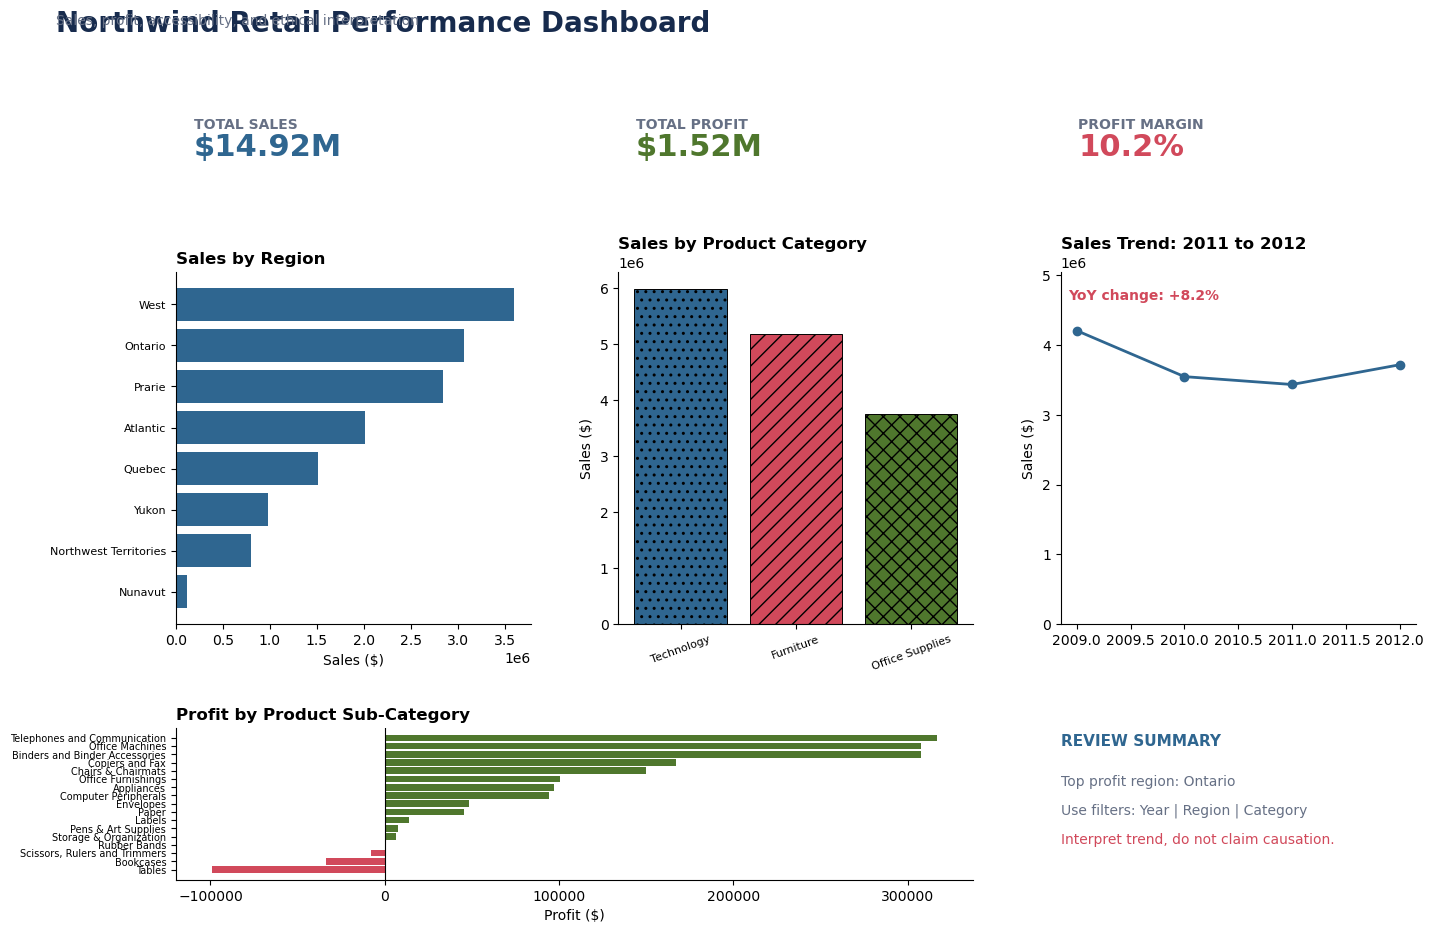

Latest-year sales change: +8.2%
Top profit region: Ontario


In [ ]:
fig.suptitle("Northwind Retail Performance Dashboard", fontsize=20,
             fontweight="bold", color="#172B4D", x=0.05, y=0.985, ha="left")
fig.text(0.05, 0.945, "Sales, profit, accessibility, and ethical interpretation",
         fontsize=10, color=gray)
plt.show()

print(f"Latest-year sales change: {yoy_change:+.1%}")
print(f"Top profit region: {region_totals.idxmax()}")

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

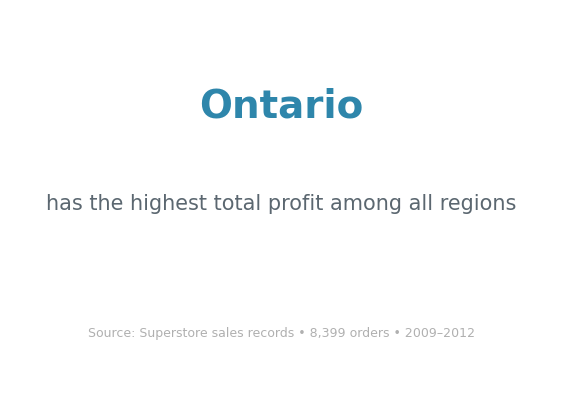

In [13]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# Primary: largest, boldest, most salient reading cue
ax.text(0.5, 0.72, best_region, ha="center", fontsize=28, fontweight="bold", color="#2E86AB")

# Secondary: supporting statement, medium size, muted color
ax.text(0.5, 0.48, "has the highest total profit among all regions", ha="center", fontsize=15, color="#5B6770")

# Tertiary: data-source note, small and light gray
ax.text(0.5, 0.15, "Source: Superstore sales records • 8,399 orders • 2009–2012", ha="center", fontsize=9, color="#B0B0B0")

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_ The eye lands on the region name first, then the supporting sentence,
and finally the footnote. In a quick two-second glance, the key takeaway is that
Ontario is the highest-profit region.


## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

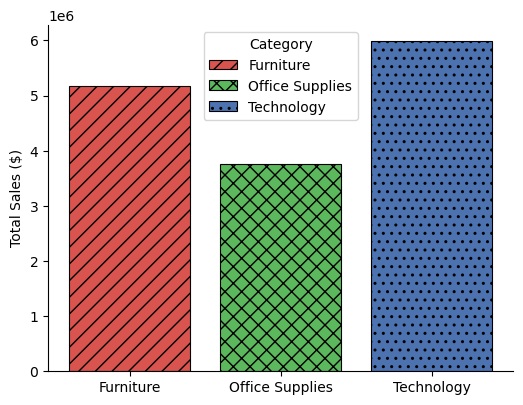

In [14]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat], edgecolor="black", linewidth=0.8)

ax.legend(cat_sales.index, title="Category")
ax.set_ylabel("Total Sales ($)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_ This would fail for colorblind viewers, because the category distinctions
would be hard to separate by hue alone, and it would also fail for grayscale-printer
or monochrome viewing, because the bars would visually collapse into similar shades and
lose their meaning.


## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

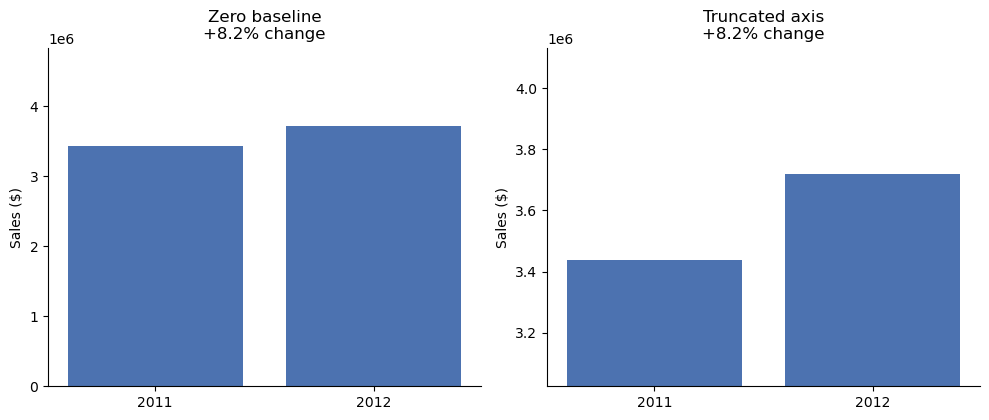

Real change from 2011 to 2012: +8.2%


In [15]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.iloc[-2], yearly_sales.iloc[-1]
pct_change = ((v2 - v1) / v1) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# Zero-baseline version
axes[0].bar([str(y1), str(y2)], [v1, v2], color=["#4C72B0", "#4C72B0"])
axes[0].set_title(f"Zero baseline\n{pct_change:+.1f}% change")
axes[0].set_ylabel("Sales ($)")
axes[0].set_ylim(0, max(v1, v2) * 1.3)

# Truncated-axis version
axes[1].bar([str(y1), str(y2)], [v1, v2], color=["#4C72B0", "#4C72B0"])
axes[1].set_title(f"Truncated axis\n{pct_change:+.1f}% change")
axes[1].set_ylabel("Sales ($)")
margin = 0.12 * min(v1, v2)
axes[1].set_ylim(min(v1, v2) - margin, max(v1, v2) + margin)

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_ I would flag the truncated-axis panel. It compresses the vertical range
around the two years and makes a modest increase look dramatic, which exaggerates the
story instead of presenting the data honestly.


## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales increased from $3.54M in 2011 to $3.72M in 2012.
INTERPRETIVE: Sales rose in 2012.
This may reflect the new strategy,
but other factors could also matter.


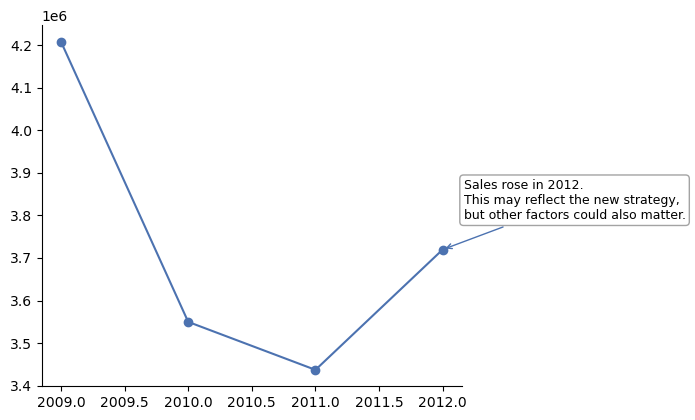

In [16]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

descriptive_version = "Sales increased from $3.54M in 2011 to $3.72M in 2012."
interpretive_version = "Sales rose in 2012.\nThis may reflect the new strategy,\nbut other factors could also matter."

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.annotate(
    interpretive_version,
    xy=(yearly_sales.index[-1], yearly_sales.iloc[-1]),
    xytext=(15, 20),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#999999", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color="#4C72B0")
)

plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_ I would need causal evidence such as a controlled before/after test or
an A/B comparison with a matched control group, plus evidence that the rise was caused
by the strategy rather than by seasonality, pricing, volume, or broader market changes.


## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_ The most urgent issue to fix before shipping is the
truncated-axis chart in Task 3, because a misleading scale can make a small change look
like a crisis and push the wrong business decision. The Ethical Visualization Audit
question I would apply is: "What is the relationship between the data and the claim being
made?" In Task 3, the axis choice changes the emotional message so much that it creates a
false impression of risk, even when the underlying sales change is modest. I recommend a
permanent pre-publish check that requires every headline chart to be reviewed for baseline
accuracy and for a clear statement of whether the annotation is descriptive, interpretive,
or causal.
